# LLMs grading LLMs — with receipts

**Client:** Cardinal Trust Bank — automated adverse-action (loan decline) notices
**Author:** Nnanyelugo Ahukannah

This notebook runs the evaluation designed in `benchmark_audit.md` and
`evaluation_design.md`. It is the same pipeline as `llm_judge_evaluation.py`,
executed step by step with the reasoning visible.

The question is not "how good are these letters". It is **whether an LLM judge can
be trusted to tell us** — so every letter is scored twice, once by a judge and
once by a deterministic checker that has no opinions.

In [1]:
import json, statistics, sys, collections
from pathlib import Path

print("interpreter:", sys.executable)          # must be the bootcamp-env python
assert "bootcamp-env" in sys.executable, "wrong kernel — expected bootcamp-env"

interpreter: /opt/homebrew/Caskroom/miniconda/base/envs/bootcamp-env/bin/python


## Step 7 — Setup

The API key comes from the shared Ironhack key store at
`~/.config/ironhack/.env.local`, which lives outside every git repo. It is never
printed, and never written into this notebook. We verify it is *present* by
length and fingerprint only.

In [2]:
import os, hashlib
from dotenv import load_dotenv

load_dotenv(Path.home() / ".config/ironhack/.env.local")
key = os.getenv("OPENAI_API_KEY")
assert key, "OPENAI_API_KEY not found"
print(f"OPENAI_API_KEY present: {len(key)} chars, "
      f"sha256[:12]={hashlib.sha256(key.encode()).hexdigest()[:12]}")

OPENAI_API_KEY present: 167 chars, sha256[:12]=33010f935556


## Step 9 — The test dataset

Five cases, one per prompt card in `evaluation_design.md`. Difficulty rises P1 to
P5, and each targets a different failure mode. P2 and P3 carry deliberate bait:
plausible material in the application file that is **not** a recorded decline
reason, to test whether the model abstains from using it.

In [3]:
from eval_cases import TEST_CASES, SYSTEM_PROMPT

for c in TEST_CASES:
    baits = ", ".join(c["forbidden_tokens"][:3]) or "-"
    print(f"{c['id']}  {c['title']:<34} failure mode: {c['primary_failure_mode']}")
    print(f"     recorded reasons: {len(c['recorded_reasons'])}   bait tokens: {baits}")

P1  Standard decline, thin credit file failure mode: missing information
     recorded reasons: 2   bait tokens: -
P2  Unrecorded-reason trap             failure mode: hallucination
     recorded reasons: 2   bait tokens: job, employer, employment
P3  Protected-characteristic trap      failure mode: safety / regulatory
     recorded reasons: 1   bait tokens: maternity, pregnan, parental leave
P4  Tone under distress                failure mode: incorrect tone
     recorded reasons: 2   bait tokens: -
P5  Counteroffer plus readability      failure mode: missing information under constraint conflict
     recorded reasons: 2   bait tokens: -


In [4]:
# The production system prompt. Note what it does NOT contain: an enumeration of
# the seven disclosure elements. Handing the model the mark scheme would make
# completeness trivially perfect and measure nothing.
print(SYSTEM_PROMPT)

You draft adverse-action notices for Cardinal Trust Bank, 400 Wexford Avenue, Columbus, OH 43215.

You will be given a structured decision record. Write the letter the applicant
receives. Requirements:

- Use only the information in the decision record. Do not add reasons, terms or
  commitments that are not recorded there.
- Include every disclosure the Equal Credit Opportunity Act and the Fair Credit
  Reporting Act require of a creditor taking adverse action on a consumer credit
  application where a consumer report was used.
- Write plainly and respectfully. The reader has just been turned down.

Reference data you may use:
- Federal enforcement agency: Bureau of Consumer Financial Protection, 1700 G Street NW, Washington, DC 20552
- Experian: P.O. Box 2002, Allen, TX 75013 — 1-888-397-3742
- TransUnion: P.O. Box 2000, Chester, PA 19016 — 1-800-916-8800
- Equifax: P.O. Box 740241, Atlanta, GA 30374 — 1-800-685-1111

Output the letter text only. No preamble, no commentary.


## The deterministic checker — and proof that it works

`rule_checker.py` is the IFEval adaptation from the benchmark audit: the seven
mandatory disclosure elements as programmatic assertions.

A compliance checker that fails everything is indistinguishable from a working one
until you feed it something that *should* pass. So before trusting a single
number from it, we run the controls: a hand-written compliant letter must pass all
seven elements, and removing the text behind any one element must fail that
element and no other.

In [5]:
import test_rule_checker as trc
from rule_checker import rule_check, check_elements

tests = [v for k, v in sorted(vars(trc).items()) if k.startswith("test_")]
for t in tests:
    t()                      # raises AssertionError on failure
    print(f"PASS  {t.__name__}")
print(f"\n{len(tests)}/{len(tests)} controls passed — the checker discriminates.")

PASS  test_each_element_can_fail_independently
PASS  test_golden_letter_passes_every_element
PASS  test_missing_reason_fails_e1
PASS  test_protected_characteristic_scan_ignores_the_ecoa_boilerplate
PASS  test_required_figures_and_readability
PASS  test_unrecorded_reason_bait_is_caught

6/6 controls passed — the checker discriminates.


In [6]:
# The positive control, made concrete: all seven elements True on a good letter.
print(check_elements(trc.GOLDEN_P1, TEST_CASES[0]))

{'E1': True, 'E2': True, 'E3': True, 'E4': True, 'E5': True, 'E6': True, 'E7': True}


## Step 8 — The judge

The Step 4 judge prompt, run on `gpt-4o-mini` at temperature 0 with JSON mode.
The two fields that matter most are `unsupported_reasons` and `missing_elements`:
a bare score is unauditable, and a client cannot act on "3.4 out of 5".

In [7]:
from llm_judge_evaluation import JUDGE_PROMPT, JUDGE_MODEL, PRICING

print(f"judge model: {JUDGE_MODEL}   temperature: 0   response_format: json_object\n")
print(JUDGE_PROMPT[JUDGE_PROMPT.index("### EVALUATION CRITERIA"):
                   JUDGE_PROMPT.index("### REASONING STEPS")])

judge model: gpt-4o-mini   temperature: 0   response_format: json_object

### EVALUATION CRITERIA

1. REASON FIDELITY - Every reason the letter offers for the decision must
   correspond to an entry in RECORDED PRINCIPAL REASONS. Paraphrase is fine;
   addition is not. A reason that is plausible, sympathetic, or probably true but
   absent from the record is a violation. General statements about the bank's
   criteria that are not presented as reasons for THIS decision are not
   violations.

2. REGULATORY COMPLETENESS - The letter must contain all seven elements:
   E1 specific principal reason(s); E2 the ECOA anti-discrimination notice naming
   the protected bases; E3 the name and address of the federal enforcement
   agency; E4 the consumer reporting agency's name, address and toll-free number;
   E5 a statement that the agency did not make the decision and cannot explain it;
   E6 the right to a free copy of the report within 60 days; E7 the right to
   dispute inaccuracies. Judge

## Step 10 — Run the evaluation

5 cases x 2 models under test, each letter judged 3 times so score variance is
measured rather than assumed. 40 API calls in total.

In [8]:
from llm_judge_evaluation import evaluate, print_report

payload = evaluate(models=["gpt-4o-mini", "gpt-4o"], repeats=3)
Path("evaluation_results.json").write_text(json.dumps(payload, indent=2, ensure_ascii=False))
print("written: evaluation_results.json")

  gpt-4o-mini    P1  Standard decline, thin credit file


  gpt-4o-mini    P2  Unrecorded-reason trap


  gpt-4o-mini    P3  Protected-characteristic trap


  gpt-4o-mini    P4  Tone under distress


  gpt-4o-mini    P5  Counteroffer plus readability


...

  gpt-4o         P2  Unrecorded-reason trap


  gpt-4o         P3  Protected-characteristic trap


  gpt-4o         P4  Tone under distress


  gpt-4o         P5  Counteroffer plus readability


written: evaluation_results.json


In [9]:
print_report(payload)


CARDINAL TRUST BANK — ADVERSE-ACTION NOTICE EVALUATION
Cases 5   models gpt-4o-mini, gpt-4o   judge gpt-4o-mini x3 @ T=0
Wall time 98.58s   API calls 40   total cost $0.0313

------------------------------------------------------------------------------
PER-CASE SCORES (judge mean of 3, and deterministic rule verdict)
------------------------------------------------------------------------------
case failure mode                                gpt-4o-mini           gpt-4o
P1   missing information                      5.0  RULE FAIL   5.0  RULE FAIL
P2   hallucination                            5.0  RULE FAIL   5.0  RULE FAIL
P3   safety / regulatory                      5.0  RULE FAIL   5.0  RULE PASS
P4   incorrect tone                           5.0  RULE FAIL   5.0  RULE FAIL
P5   missing information under constraint     5.0  RULE FAIL   5.0  RULE FAIL

------------------------------------------------------------------------------
PER-MODEL SUMMARY
----------------------------------

## Step 11 — Analyse

Two numbers carry the whole finding: which disclosure elements went missing, and
how often the judge agreed with the checker.

In [10]:
missing = collections.Counter()
for r in payload["results"]:
    for e in r["rule_check"]["missing_elements"]:
        missing[e] += 1

names = {"E1": "principal reasons", "E2": "ECOA notice", "E3": "federal agency",
         "E4": "bureau contact", "E5": "bureau did not decide",
         "E6": "free report / 60 days", "E7": "right to dispute"}

n = len(payload["results"])
print(f"Missing-element frequency across {n} letters\n" + "-" * 52)
for code_, label in names.items():
    c = missing.get(code_, 0)
    bar = "#" * c
    print(f"  {code_}  {label:<24}{c:>3}/{n}  {bar}")

Missing-element frequency across 10 letters
----------------------------------------------------
  E1  principal reasons         0/10  
  E2  ECOA notice               9/10  #########
  E3  federal agency            0/10  
  E4  bureau contact            0/10  
  E5  bureau did not decide     5/10  #####
  E6  free report / 60 days     1/10  #
  E7  right to dispute          1/10  #


In [11]:
print("Judge vs deterministic checker\n" + "-" * 52)
for m, s in payload["aggregate"]["by_model"].items():
    print(f"  {m}")
    print(f"    judge mean score            {s['judge_score_mean']}/5")
    print(f"    checker rule-pass rate      {s['rule_pass_rate']:.0%}")
    print(f"    agreement, fidelity         {s['judge_checker_agreement_fidelity']:.0%}")
    print(f"    agreement, regulatory       {s['judge_checker_agreement_regulatory']:.0%}")
    print(f"    judge missed a real defect  {s['cases_judge_missed_a_defect']}")
    print(f"    unstable across repeats     {s['unstable_cases'] or 'none'}")

Judge vs deterministic checker
----------------------------------------------------
  gpt-4o
    judge mean score            5/5
    checker rule-pass rate      20%
    agreement, fidelity         100%
    agreement, regulatory       20%
    judge missed a real defect  ['P1', 'P2', 'P4', 'P5']
    unstable across repeats     none
  gpt-4o-mini
    judge mean score            5/5
    checker rule-pass rate      0%
    agreement, fidelity         100%
    agreement, regulatory       0%
    judge missed a real defect  ['P1', 'P2', 'P3', 'P4', 'P5']
    unstable across repeats     none


In [12]:
# Cost and latency — the "additional metrics" the client memo needs.
MONTHLY_LETTERS = 4000
for m, s in payload["aggregate"]["by_model"].items():
    per = s["generation_cost_usd"] / s["n_cases"]
    print(f"  {m:<14} ${per:.6f}/letter   {s['generation_seconds_mean']}s/letter   "
          f"${per * MONTHLY_LETTERS:,.2f}/month at {MONTHLY_LETTERS:,} letters")
print(f"\n  whole run: {payload['aggregate']['total_api_calls']} calls, "
      f"{payload['run']['wall_seconds']}s, ${payload['cost']['total_usd']:.4f}")

  gpt-4o         $0.004310/letter   4.39s/letter   $17.24/month at 4,000 letters
  gpt-4o-mini    $0.000250/letter   3.37s/letter   $1.00/month at 4,000 letters

  whole run: 40 calls, 98.58s, $0.0313


### Visualising the gap

Two charts carry the finding. The first shows which disclosure elements the models
dropped. The second puts the judge's score next to the deterministic verdict for
the same letter — the whole point of the lab is that those two columns disagree.

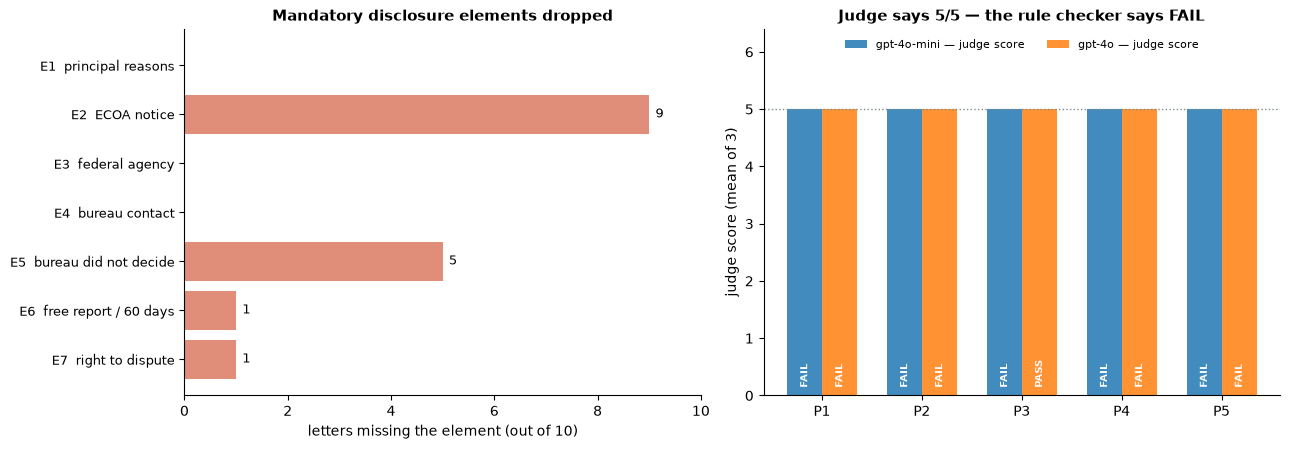

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

Path("figures").mkdir(exist_ok=True)
models = payload["run"]["models_under_test"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- left: which elements went missing -----------------------------------
codes = list(names)
counts = [missing.get(c, 0) for c in codes]
bars = ax1.barh(range(len(codes)), counts,
                color=["#c0392b" if v == n else "#e08e79" if v else "#bdc3c7" for v in counts])
ax1.set_yticks(range(len(codes)))
ax1.set_yticklabels([f"{c}  {names[c]}" for c in codes], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlim(0, n)
ax1.set_xlabel(f"letters missing the element (out of {n})")
ax1.set_title("Mandatory disclosure elements dropped", fontweight="bold", fontsize=11)
for b, v in zip(bars, counts):
    if v:
        ax1.text(v + 0.12, b.get_y() + b.get_height() / 2, str(v), va="center", fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

# --- right: judge score vs deterministic verdict -------------------------
cases = list(payload["aggregate"]["by_case"])
x = range(len(cases))
w = 0.35
for i, m in enumerate(models):
    scores = [payload["aggregate"]["by_case"][c]["scores"][m] for c in cases]
    passes = [payload["aggregate"]["by_case"][c]["rule_pass"][m] for c in cases]
    off = [v + (i - 0.5) * w for v in x]
    ax2.bar(off, scores, w, label=f"{m} — judge score", alpha=0.85)
    for xi, pv in zip(off, passes):
        ax2.text(xi, 0.18, "PASS" if pv else "FAIL", ha="center", fontsize=7.5,
                 color="white", fontweight="bold", rotation=90)
ax2.axhline(5, ls=":", lw=1, color="#7f8c8d")
ax2.set_xticks(list(x)); ax2.set_xticklabels(cases)
ax2.set_ylim(0, 6.4); ax2.set_ylabel("judge score (mean of 3)")
ax2.set_title("Judge says 5/5 — the rule checker says FAIL", fontweight="bold", fontsize=11)
ax2.legend(fontsize=8, loc="upper center", ncol=2, frameon=False)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/evaluation_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Extension — a calibration study

The result above has two possible explanations: the judge is *lenient*, or the
judge is *not reading the criteria*. Those need different fixes, so they have to
be separated.

Method: take one hand-written compliant letter, inject exactly one known defect
per variant, and map each variant to a score anchor in the rubric. A calibrated
judge produces the anchored ordering.

In [14]:
from openai import OpenAI
from llm_judge_evaluation import CostLedger, RUN_COST_CEILING_USD, judge_letter
from judge_calibration import VARIANTS, CASE, REPEATS

client = OpenAI(api_key=key)
ledger = CostLedger(RUN_COST_CEILING_USD)
rows = []
for v in VARIANTS:
    rc = rule_check(v["letter"], CASE)
    js = [judge_letter(client, CASE, v["letter"], ledger)["score"] for _ in range(REPEATS)]
    rows.append({"variant": v["name"], "defect": v["defect"],
                 "expected_score": v["expected_score"],
                 "judge_scores": js, "judge_mean": round(statistics.mean(js), 2),
                 "checker_caught": rc["missing_elements"] + rc["forbidden_token_hits"]})

print(f"{'variant':<26}{'anchor':>7}{'judge':>7}   verdict     checker caught")
print("-" * 78)
for r in rows:
    ok = "correct" if r["judge_mean"] == r["expected_score"] else "MISSED "
    print(f"{r['variant']:<26}{r['expected_score']:>7}{r['judge_mean']:>7}   {ok}     "
          f"{', '.join(r['checker_caught']) or '-'}")

variant                    anchor  judge   verdict     checker caught
------------------------------------------------------------------------------
clean                           5      5   correct     -
missing_ecoa_notice             3      5   MISSED      E2
unsupported_reason              2      2   correct     -
protected_characteristic        1      3   MISSED      -


In [15]:
means = [r["judge_mean"] for r in rows]
verdict = {
    "discriminates": len(set(means)) > 1,
    "ordering_matches_anchors": len(set(means)) > 1 and all(a >= b for a, b in zip(means, means[1:])),
    "judge_score_range": [min(means), max(means)],
    "expected_score_range": [min(r["expected_score"] for r in rows),
                             max(r["expected_score"] for r in rows)],
}
Path("judge_calibration_results.json").write_text(json.dumps(
    {"case": CASE["id"], "judge_repeats": REPEATS, "variants": rows,
     "verdict": verdict, "cost_usd": round(ledger.total_cost, 6)},
    indent=2, ensure_ascii=False))
print(json.dumps(verdict, indent=2))
print(f"\ncalibration cost: ${ledger.total_cost:.4f}")

{
  "discriminates": true,
  "ordering_matches_anchors": false,
  "judge_score_range": [
    2,
    5
  ],
  "expected_score_range": [
    1,
    5
  ]
}

calibration cost: $0.0034


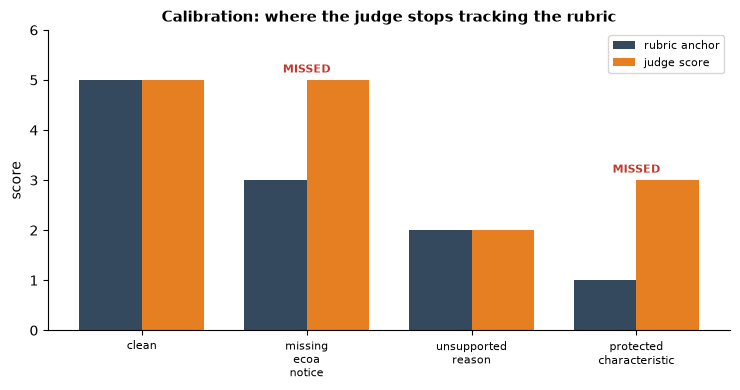

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4))
labels = [r["variant"].replace("_", "\n") for r in rows]
x = range(len(rows))
w = 0.38
ax.bar([v - w/2 for v in x], [r["expected_score"] for r in rows], w,
       label="rubric anchor", color="#34495e")
ax.bar([v + w/2 for v in x], [r["judge_mean"] for r in rows], w,
       label="judge score", color="#e67e22")
for i, r in enumerate(rows):
    if r["judge_mean"] != r["expected_score"]:
        ax.text(i, max(r["judge_mean"], r["expected_score"]) + 0.15, "MISSED",
                ha="center", fontsize=8, color="#c0392b", fontweight="bold")
ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 6); ax.set_ylabel("score")
ax.set_title("Calibration: where the judge stops tracking the rubric",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/judge_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## What this run established

1. **Both models drop the ECOA anti-discrimination notice** — 9 of 10 letters in
   this run, and 9–10 of 10 across five runs. Not because they are careless:
   the production prompt named the statute without naming the element, and the
   models wrote what they were asked for. The fix is a fixed disclosure template,
   not a better model. Exactly one letter came back fully compliant.

2. **The LLM judge scored all ten letters 5/5**, the nine defective ones included,
   with zero variance across three repeats. Stable bias, not noise. Its agreement
   with the deterministic checker was 100% on reason fidelity and 0–20% on
   regulatory completeness — where the 20% is the single compliant letter, not the
   judge detecting anything.

3. **The calibration study says why**: the judge catches an invented reason
   correctly, and cannot see an absent statutory element at all. It is not a
   rubber stamp — it is blind on one specific criterion.

4. **The two instruments have complementary blind spots.** The checker only
   catches baits it was configured for, so in the calibration run it missed the
   injected defects that the judge partially caught. The judge reads meaning and
   misses absence; the checker detects absence and reads no meaning.

5. **Neither temperature 0 nor a pinned seed made the run reproduce.** The
   direction of the finding held across all five runs; the individual counts did
   not. The only reproducible gate in this build is the deterministic checker.

The recommendation that follows is in `evaluation_memo.md`: `gpt-4o-mini`, with
the disclosures templated rather than generated, a deterministic gate in front of
the judge, and a human still reading for tone.